In [1]:
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette
from autoslo.workload_execution.trace import Trace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [24]:
pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]
rpus = [4, 8, 16, 32]

slo_s = 180

records = []

for pct_heavy in pct_heavy_options:
    for mean_interarrival in mean_interarrival_options:
        for rpu in rpus:
            run_id = pu.RunLocator.get_run_ids(
                workload_name="{}pctheavy_{}meaninterarrival".format(
                    pct_heavy, mean_interarrival
                ),
                blueprint_name=f"single_{rpu}",
            )[-1]

            trace = Trace(run_id)
            latencies = trace.latencies_s
            costs = trace.costs

            records.append({
                "type": "baseline",
                "pct_heavy": pct_heavy,
                "mean_interarrival": mean_interarrival,
                "rpu": rpu,
                "run_id": run_id,
                "slo_violation_rate": np.mean([1 if lat > slo_s else 0 for lat in latencies]), 
                "total_cost": sum(costs),
                "slo_violation_time": np.sum([max(0, lat - slo_s) for lat in latencies])
            })



In [25]:
run_id = pu.RunLocator.get_run_ids(
            query_router_name=f"SeqNum",
        )[-1]
run_id

trace = Trace(run_id)
latencies = trace.latencies_s
costs = trace.costs

records.append({
    "type": "ours_seqnum",
    "pct_heavy": 25,
    "mean_interarrival": 30,
    "rpu": "Ours",
    "run_id": run_id,
    "slo_violation_rate": np.mean([1 if lat > slo_s else 0 for lat in latencies]), 
    "total_cost": sum(costs),
    "slo_violation_time": np.sum([max(0, lat - slo_s) for lat in latencies])
})

In [26]:
records_df = pd.DataFrame(records)
records_df

,type,pct_heavy,mean_interarrival,rpu,run_id,slo_violation_rate,total_cost,slo_violation_time
0,baseline,0,10,4,1763346358,0.755224,10.007500,661500.303626
1,baseline,0,10,8,1765440646,0.794030,15.727500,484008.240136
2,baseline,0,10,16,1763304261,0.435821,11.866667,118989.054410
3,baseline,0,10,32,1763978737,0.038806,11.626667,976.994462
4,baseline,0,30,4,1763336464,0.728070,3.867083,224208.574519
...,...,...,...,...,...,...,...,...
60,baseline,50,120,4,1763323616,0.840000,1.916667,21451.689375
61,baseline,50,120,8,1765423765,0.360000,2.436667,1355.973452
62,baseline,50,120,16,1763291740,0.040000,3.183333,129.655538
63,baseline,50,120,32,1763966257,0.000000,5.000000,0.000000


In [27]:
records_df[records_df['pct_heavy'] == 25][records_df['mean_interarrival'] == 30]

/tmp/ipykernel_1568762/3599556109.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  records_df[records_df['pct_heavy'] == 25][records_df['mean_interarrival'] == 30]


,type,pct_heavy,mean_interarrival,rpu,run_id,slo_violation_rate,total_cost,slo_violation_time
36,baseline,25,30,4,1763299556,0.621849,2.590833,107321.088430
37,baseline,25,30,8,1765404304,0.613445,3.954167,71856.646293
38,baseline,25,30,16,1763282675,0.008403,4.813333,40.338225
39,baseline,25,30,32,1763957798,0.000000,9.273333,0.000000
64,ours_seqnum,25,30,Ours,1768517631,0.008403,3.650833,8.168437


In [42]:
9.273333/3.650833

2.5400594877936076

In [43]:
40.338225/8.168437

4.938303986429717

In [28]:
# Plot a 4X4 grid of chunks. In each subplot, have a scatterplot where the
# x-axis is the total cost and the y-axis is the SLO violation rate. Have each
# value of RPU be a different color.

# Make all the fonts 14 pt
plt.rcParams.update({"font.size": 20})



colors = {
    4: Palette.light_yellow,
    8: Palette.light_orange,
    16: Palette.light_red,
    32: Palette.dark_orange,
    "ours": Palette.light_blue
}

def plot_one_panel(ax, pct_heavy, mean_interarrival, plot_time=False):
    subset = records_df[
        (records_df["pct_heavy"] == pct_heavy)
        & (records_df["mean_interarrival"] == mean_interarrival)
    ]

    xcolname = "slo_violation_rate" if not plot_time else "slo_violation_time"

    for rpu in rpus:
        rpu_subset = subset[subset["rpu"] == rpu]
        ax.scatter(
            rpu_subset[xcolname],
            rpu_subset["total_cost"],
            label=f"All on {rpu} RPU",
            s=300,
            color=colors[rpu],
        )
    # Plot our method
    ours_subset = subset[subset["rpu"] == "Ours"]
    if len(ours_subset) > 0:
        ax.scatter(
            ours_subset[xcolname],
            ours_subset["total_cost"],
            label="Ours (Exact)",
            s=300,
            color=colors["ours"],
            marker="*",
        )
    ax.set_title(
        f"{pct_heavy}% Heavy, Mean T={mean_interarrival}s"
    )



In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 15), sharex=True, sharey=True)


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]
        plot_one_panel(ax, pct_heavy, mean_interarrival)
        if i == 0 and j == 0:
            ax.legend()

fig.supxlabel("SLO Violation Rate")
fig.supylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.ylim(0.8, 20)
plt.tight_layout()
plt.savefig("chunk_grid.svg")
plt.show()

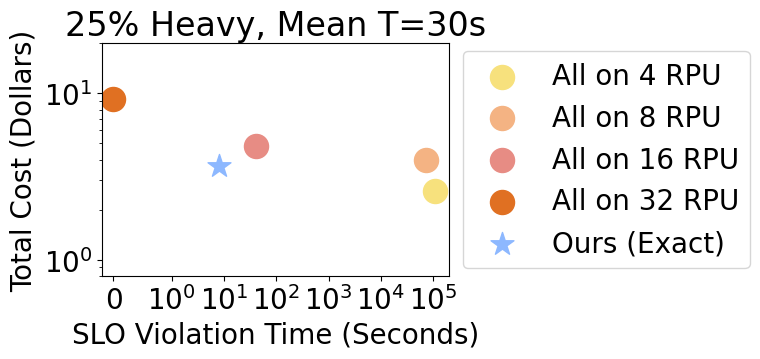

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True, sharey=True)



plot_one_panel(ax, 25, 30, plot_time=True)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

ax.set_xlabel("SLO Violation Time (Seconds)")
ax.set_ylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.ylim(0.8, 20)
plt.xscale("symlog", linthresh=1)
# Show minor x ticks
plt.minorticks_on()
plt.xlim(left=-0.2, right=200000)
plt.tight_layout()
plt.savefig("chunk_grid_one.svg", bbox_inches="tight")
plt.show()